# 04. Seaborn

Seaborn이란, Matplotlib 기반의 통계 데이터 시각화 라이브러리

> 작성 환경: seaborn 0.13.2
> 데이터: seaborn 내장 데이터셋 (tips, fmri, titanic)

### 주의: 02·03번의 titanic과 다른 데이터다

02·03번은 캐글 `titanic.csv`, 이 노트북은 `sns.load_dataset("titanic")`을 쓴다.
**컬럼 이름이 다르므로 코드를 복사해 오면 KeyError가 난다.**

| 02·03번 (캐글) | 04번 (seaborn) |
|---|---|
| `Survived`, `Pclass`, `Age`, `Fare` | `survived`, `pclass`, `age`, `fare` |
| `Cabin` | `deck` |
| `Name`, `Ticket`, `PassengerId` | **없음** |
| — | `alive`, `who`, `alone` 추가로 있음 |

seaborn 버전은 컬럼명이 전부 **소문자**다.

---

## 주요 특징
- **통계 시각화**: 평균, 신뢰구간, 분포를 알아서 계산해서 그려준다
- **Matplotlib 기반**: seaborn이 내부에서 matplotlib을 호출한다.
  그래서 `plt.title()` 같은 함수로 꾸미기가 그대로 된다
- **Pandas 통합**: DataFrame과 컬럼 이름만 넘기면 된다.
  데이터를 직접 쪼개서 집계할 필요가 없다

### matplotlib과의 관계
seaborn은 matplotlib을 **대체하는 게 아니라 위에 얹힌 층**이다.
보통 seaborn으로 그리고, 제목·축·크기는 matplotlib으로 손본다.

---

## 기본 세팅

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib   # 한글 제목이 깨지지 않게

sns.set_theme(style="whitegrid")   # seaborn 기본 스타일

print(sns.__version__)

---

## figure-level vs axes-level 함수
| 데이터 목적 | 고레벨 함수(기본형) | 저레벨 함수(세부 차트) | 설명 |
| --- | --- | --- | --- |
|관계형(Relational) | sns.relplot() | scatterplot(), lineplot() | 두 수치형 변수의 상관관계나 추이를 볼 때 |
|범주형(Categorical) | sns.catplot() | barplot(), boxplot(), violinplot() | 그룹/항목 간의 크기나 분포를 비교할 때 |
| 분포형(Distribution)	| sns.displot() | histplot(), kdeplot() | 하나의 변수가 가진 통계적 분포를 볼 때|

### 두 종류의 결정적 차이

| | axes-level (scatterplot 등) | figure-level (relplot 등) |
|---|---|---|
| 무엇을 만드나 | **Axes 하나**에 그린다 | **Figure를 통째로** 새로 만든다 |
| `ax=` 인자 | 있다 → 원하는 칸 지정 가능 | **없다** |
| subplots 안에 넣기 | 가능 | **불가능** |
| 꾸미기 | `plt.title()` 그대로 | `g.fig.suptitle()` 등 따로 |
| 여러 칸으로 쪼개기 | 직접 subplots를 만들어야 함 | `col=`, `row=` 한 줄 |

**가장 많이 걸리는 지점:**
03번에서 만든 대시보드처럼 `ax[0]`, `ax[1]`에 나눠 그리고 싶을 때
figure-level 함수는 넣을 수 없다. 자기 Figure를 따로 만들기 때문이다.

In [ ]:
tips = sns.load_dataset("tips")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# axes-level: ax= 로 칸을 지정할 수 있다
sns.scatterplot(data=tips, x="total_bill", y="tip", ax=ax[0])
ax[0].set_title("axes-level: 칸 지정 가능")

sns.boxplot(data=tips, x="day", y="total_bill", ax=ax[1])
ax[1].set_title("두 번째 칸")

plt.tight_layout()
plt.show()

In [ ]:
# figure-level은 ax= 인자가 없다 → 에러가 난다
sns.relplot(data=tips, x="total_bill", y="tip", ax=ax[0])
# TypeError: relplot() got an unexpected keyword argument 'ax'

---

## seaborn의 핵심 인자

| 인자 | 역할 |
|---|---|
| `data=` | DataFrame을 통째로 넘긴다 |
| `x=`, `y=` | **컬럼 이름(문자열)**으로 지정 |
| `hue=` | 값에 따라 **색**을 나눈다 |
| `style=` | 값에 따라 **점 모양**을 나눈다 |
| `size=` | 값에 따라 **점 크기**를 나눈다 |
| `col=`, `row=` | **칸을 나눠서** 따로 그린다 (figure-level 전용) |

### matplotlib과의 차이가 여기서 난다

성별로 색을 나누려면 —

matplotlib: 데이터를 직접 쪼개서 두 번 그려야 한다
```python
plt.scatter(남자df["total_bill"], 남자df["tip"], c="blue")
plt.scatter(여자df["total_bill"], 여자df["tip"], c="red")
plt.legend(["남", "여"])
```

seaborn: `hue="sex"` 한 줄. 범례도 자동으로 붙는다

**이게 "Pandas 통합"의 실제 의미다.** 컬럼 이름만 넘기면 그룹 분리와 집계를 알아서 한다.

---

## Axes-level 함수

### 관계형 차트(scatteplot, lineplot)

In [3]:
# seaborn 내장함수인 tips 불러오기
tips = sns.load_dataset("tips")

In [ ]:
# 데이터 정보 살펴보기
type(tips)

tips.info()

print(tips.shape)

print(tips.columns.tolist())

tips.head()

pandas.DataFrame

In [8]:
tips.columns # ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

<Axes: xlabel='total_bill', ylabel='tip'>

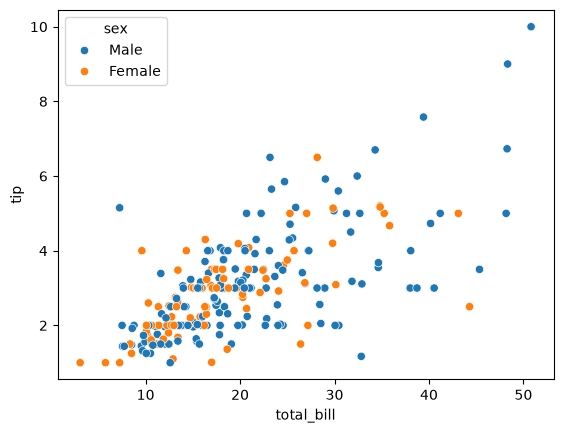

In [ ]:
# scatterplot
# 성별로 색깔을 다르게 해서 total_bill에 따른 tip의 산점도
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex")
plt.title("총 금액과 팁의 관계 (성별)")
plt.show()

<Axes: xlabel='total_bill', ylabel='tip'>

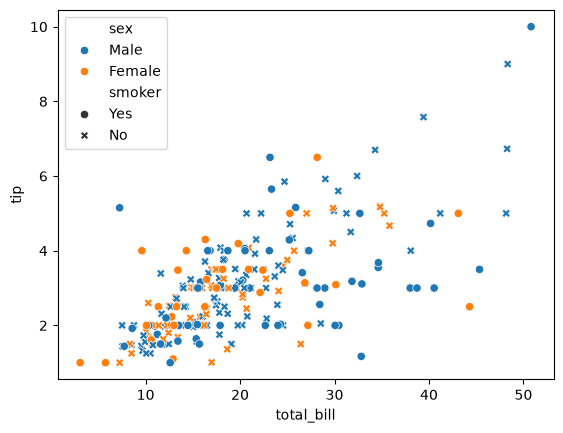

In [ ]:
# 성별로 색깔을 다르게, 흡연 여부에 따라 점 모양을 다르게 해서 total_bill에 따른 tip의 산점도
sns.scatterplot(x="total_bill", y="tip", hue="sex", style="smoker", data=tips)
plt.title("성별(색) × 흡연여부(모양)")
plt.show()

### 여기서 읽어낸 것

총 금액이 클수록 팁도 커지는 **양의 관계**가 보인다.
다만 금액이 커질수록 점이 위아래로 더 넓게 퍼진다
→ 비싼 식사일수록 팁 비율의 편차가 크다.

---

In [ ]:
# seaborn 내장함수인 fmri 불러오기
fmri = sns.load_dataset("fmri")

print(fmri.shape)                         # (1064, 5)
print(fmri["timepoint"].nunique())        # 고유 시점 개수
print(fmri[fmri["timepoint"] == 0].shape) # 시점 0에 측정값이 몇 개인가
fmri.head(3)

In [12]:
# 데이터 정보 살펴보기
fmri.columns # ['subject', 'timepoint', 'event', 'region', 'signal']

Index(['subject', 'timepoint', 'event', 'region', 'signal'], dtype='str')

<Axes: xlabel='timepoint', ylabel='signal'>

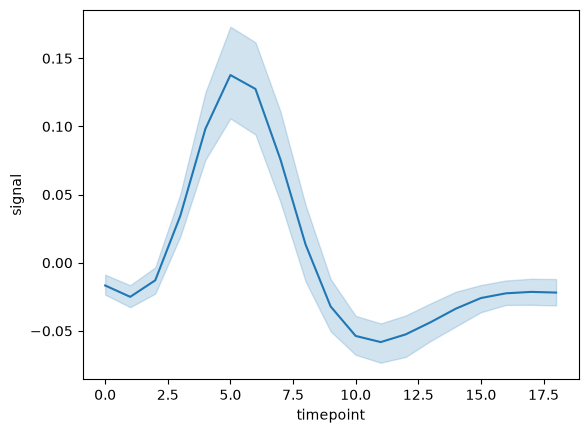

In [ ]:
#lineplot
sns.lineplot(data=fmri, x="timepoint", y="signal")
plt.title("시점별 신호 (평균 + 95% 신뢰구간)")
plt.show()

### 선 주위의 반투명한 띠는 무엇인가

fmri 데이터는 같은 timepoint에 **여러 측정값**이 들어있다
(피험자 여러 명 × 조건 여러 개). 위 셀에서 확인한 그대로다.

matplotlib의 `plot()`은 x 하나에 y 하나만 받으므로 직접 평균을 내야 한다.
seaborn의 `lineplot()`은 알아서 처리한다.

- **선** = 각 timepoint의 **평균**
- **띠** = **95% 신뢰구간** (그 평균이 들어갈 범위)

띠가 넓다 = 측정값이 들쭉날쭉 = 평균을 믿기 어렵다
띠가 좁다 = 값이 일관된다

**"통계 시각화 라이브러리"라는 말의 실제 의미가 이것이다.**
집계와 불확실성 표시를 함수 하나가 한다.

### 범주형 차트 (barplot, countplot, boxplot)

두 축 중 **적어도 한 축에 범주형(문자열) 데이터**가 들어가서 그룹을 나눈다.

| 함수 | 무엇을 보여주나 |
|---|---|
| `sns.barplot()` | 그룹별 **평균값** |
| `sns.countplot()` | 그룹별 **데이터 개수(빈도)** |
| `sns.boxplot()` | 그룹별 **통계 분포** |

**barplot과 countplot을 헷갈리지 마라.** barplot의 막대 높이는 개수가 아니라 평균이다.

<Axes: xlabel='pclass', ylabel='age'>

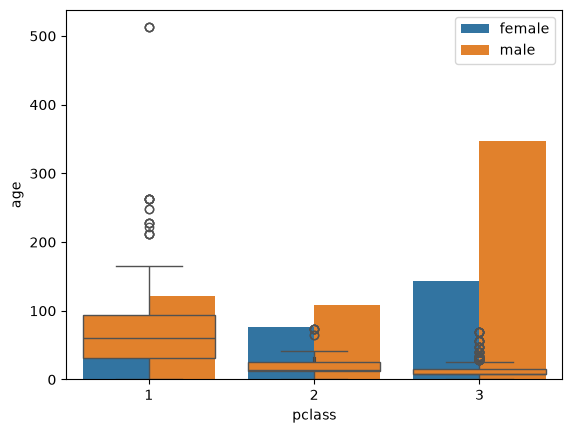

In [ ]:
# seaborn 내장함수인 titanic 불러오기
titanic = sns.load_dataset("titanic")
print(titanic.columns.tolist())
titanic.head(3)

In [ ]:
sns.barplot(data=titanic, x="pclass", y="age")
plt.title("등급별 평균 나이")
plt.show()

### barplot의 막대와 세로선

- **막대 높이** = 그 그룹의 **평균값** (개수가 아니다)
- **막대 위 검은 세로선** = 신뢰구간. 평균이 흔들릴 수 있는 범위

03번에서는 평균을 직접 냈다
    df.groupby("Pclass")["Fare"].mean()
seaborn은 그 집계를 함수가 한다.

In [ ]:
sns.countplot(data=titanic, x="pclass", hue="sex")
plt.title("등급별 성별 인원 수")
plt.show()

In [ ]:
sns.boxplot(data=titanic, x="pclass", y="fare")
plt.title("등급별 요금 분포")
plt.show()

박스플롯 읽는 법은 `03_matplotlib.ipynb` 참고.

03번에서는 등급별 비교를 위해 리스트 컴프리헨션으로 데이터를 쪼갰다
    [df[df["Pclass"]==i]["Age"] for i in [1,2,3]]
seaborn은 `x="pclass"` 한 줄로 끝난다. 이게 "Pandas 통합"의 실제 차이다.

### 분포형 차트 (histplot, kdeplot)

기본적으로 **X축 하나에만 수치형 데이터**를 넣는다.

| 함수 | 무엇을 하나 |
|---|---|
| `sns.histplot()` | 구간별 빈도. 구간 나누기를 알아서 한다 |
| `sns.kdeplot()` | 부드러운 곡선으로 분포를 추정 |

### kdeplot이란

히스토그램은 bins를 몇으로 두느냐에 따라 모양이 달라진다(03번 참고).
kdeplot은 구간 나누기 없이 곡선으로 분포를 추정한다.

- **장점**: bins에 따라 해석이 흔들리지 않는다
- **단점**: 실제 데이터에 없는 매끄러움을 만들어낸다.
  곡선이 음수 나이까지 살짝 뻗는 것도 그 때문이다
- **y축은 인원 수가 아니라 밀도**다. 전체 면적이 1이 되도록 맞춘 값

<Axes: xlabel='age', ylabel='Count'>

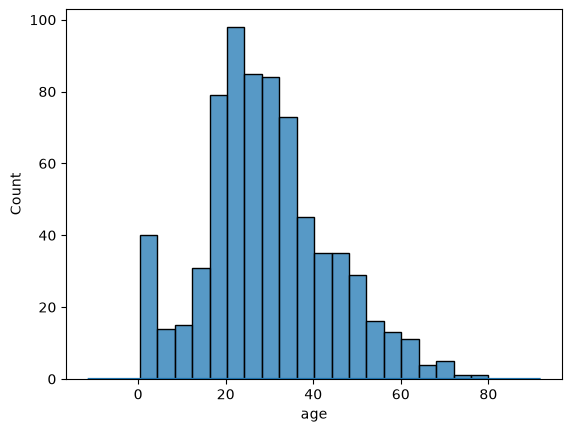

In [ ]:
sns.histplot(data=titanic, x="age", kde=True)
plt.title("나이 분포 (히스토그램 + 밀도곡선)")
plt.show()

In [ ]:
sns.kdeplot(data=titanic, x="age", hue="sex")
plt.title("성별 나이 분포")
plt.show()

### 다차원 EDA (pairplot, heatmap)

변수가 여러 개일 때 서로 어떤 관계인지 한눈에 보는 도구.

| 함수 | 무엇을 하나 |
|---|---|
| `sns.pairplot()` | 모든 수치형 변수를 쌍으로 짝지어 산점도 |
| `sns.heatmap()` | 상관계수를 색으로 표현한 격자 |

### pairplot
변수가 n개면 그래프가 n²개 생긴다.
**변수가 10개를 넘으면 쓰지 마라.** 보이지도 않고 느리다.
대각선은 자기 자신이라 산점도 대신 분포가 들어간다.

### 상관계수 읽는 법

두 변수가 같이 움직이는 정도를 **-1 ~ 1** 사이 숫자로 나타낸 것.

- **+1에 가까움**: 한쪽이 커지면 다른 쪽도 커진다
- **0에 가까움**: 관계가 없다
- **-1에 가까움**: 한쪽이 커지면 다른 쪽은 작아진다

대각선이 전부 1인 이유: 자기 자신과의 상관이라서.

**주의 1:** 상관이 있다고 인과가 있는 건 아니다.
**주의 2:** 직선 관계만 잡아낸다. U자 모양 관계는 0으로 나온다.

<Axes: >

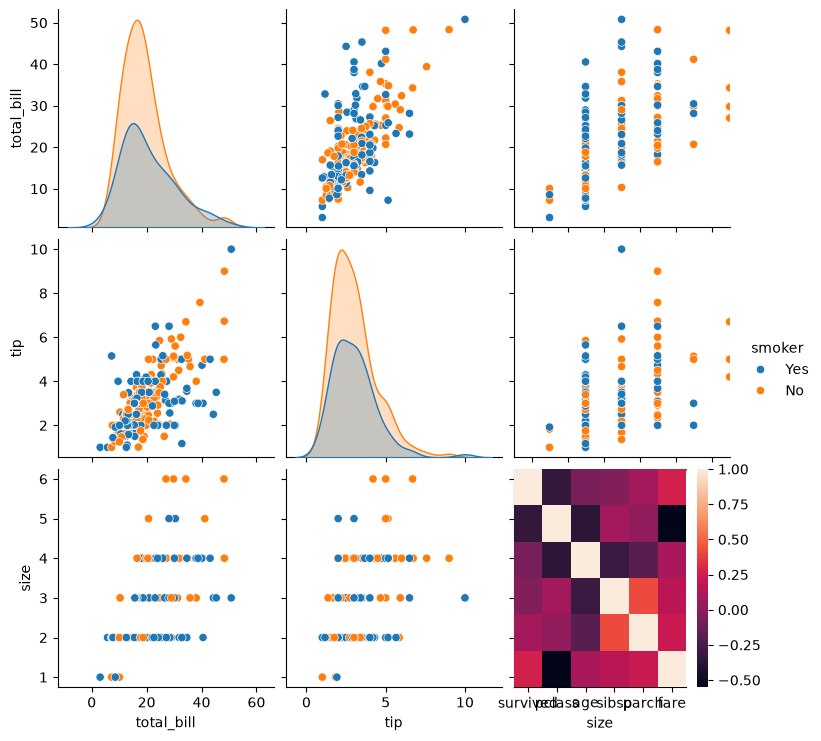

In [ ]:
sns.pairplot(tips, hue="smoker")
plt.show()

In [ ]:
numeric_df = titanic.select_dtypes(include=[np.number])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1)
plt.title("수치형 변수 간 상관계수")
plt.show()

### 여기서 읽어낸 것

`pclass`와 `fare`가 뚜렷한 **음의 상관**으로 나온다.
등급 숫자가 **작을수록 상위 등급**(1등급)이라 요금이 비싸기 때문이다.

숫자가 작은 쪽이 좋은 등급이라는 걸 모르면 이 음수를 해석할 수 없다.
**상관계수는 데이터의 의미를 알아야 읽힌다.**

---

## Figure-level 함수
매핑 공식
1. sns.relplot() 관계형 마스터
- kind='scatter' ──> 내부적으로 scatterplot() 실행
- kind='line' ──> 내부적으로 lineplot() 실행  
2. sns.catplot() (범주형 마스터)
- kind='bar' ──> 내부적으로 barplot() 실행
- kind='box' ──> 내부적으로 boxplot() 실행
- kind='count' ──> 내부적으로 countplot() 실행  
3. sns.displot() (분포형 마스터)
- kind='hist' ──> 내부적으로 histplot() 실행
- kind='kde' ──> 내부적으로 kdeplot() 실행

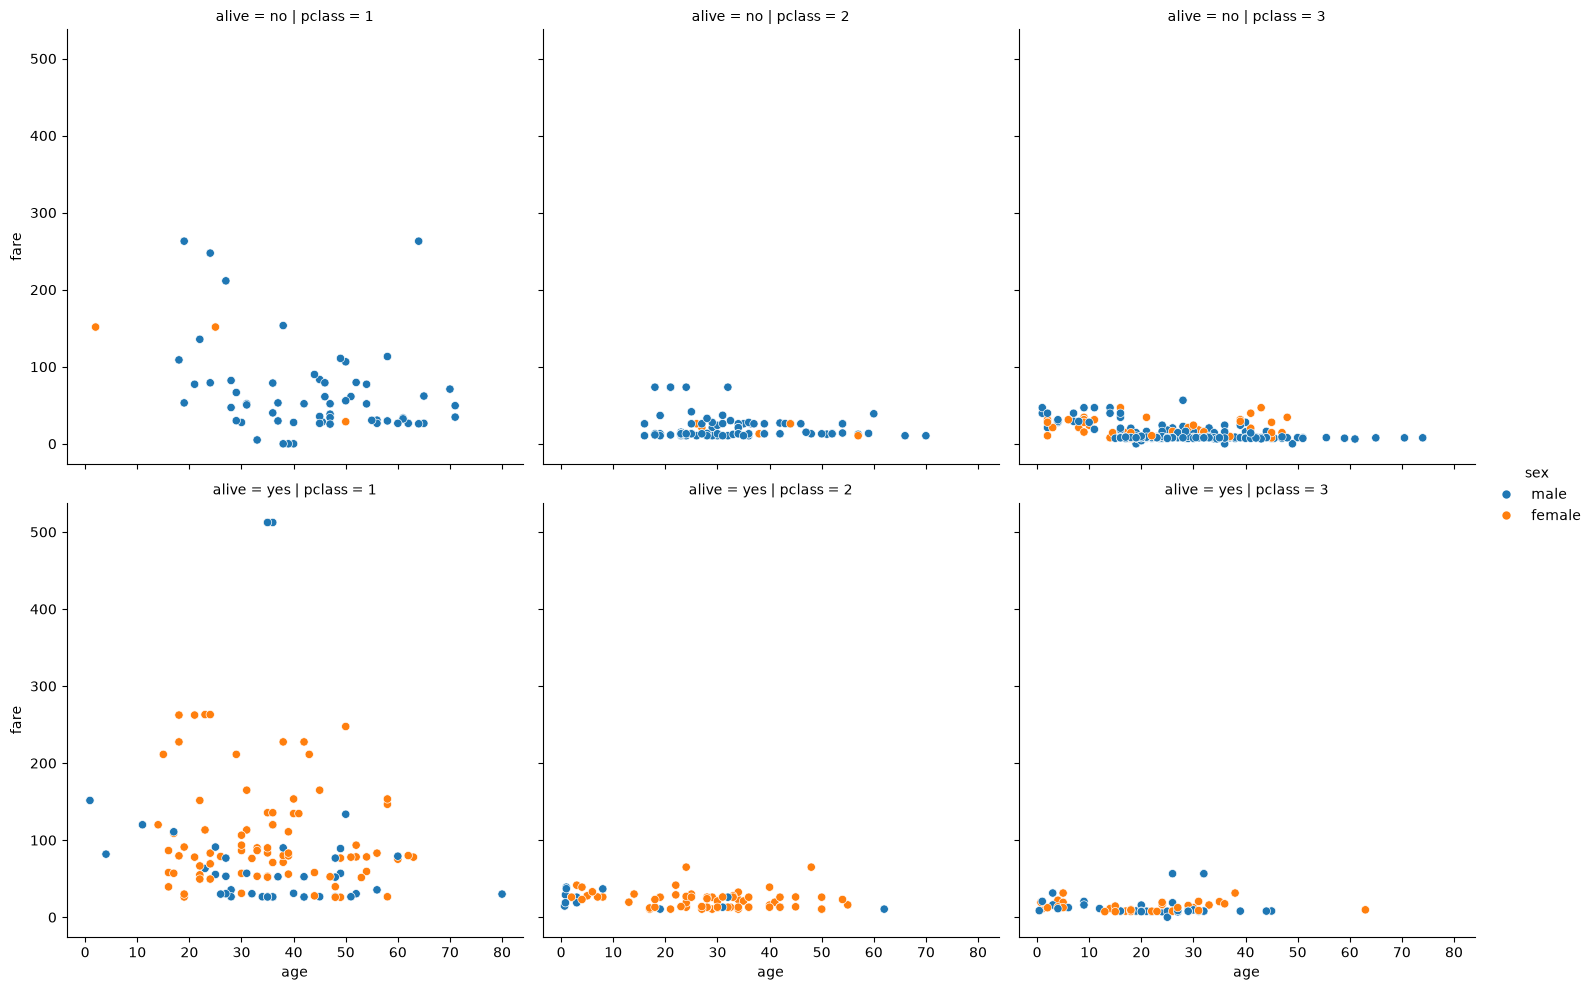

In [ ]:
# 각 열은 pclass=1/pclass=2/pclass=3,
# 각 행은 alive=no/alive=yes로
# 6개의 부분 그래프로 sex별 나이에 따른 요금 분석
sns.relplot(data=titanic, x='age', y='fare', hue='sex', col='pclass', row='alive', kind='scatter')
plt.show()

`col="pclass"` → 열 3개 (1, 2, 3등급)
`row="alive"`  → 행 2개 (사망 / 생존)
→ 3 × 2 = **6칸**

**이걸 axes-level로 하려면** `plt.subplots(2, 3)`을 만들고
데이터를 6번 쪼개서 각 ax에 그려야 한다.
figure-level은 `col=`, `row=` 두 줄이면 끝난다.
→ 대신 `ax=` 로 기존 칸에 끼워 넣을 수 없다.

**이게 두 종류를 나눠 쓰는 이유다.** (앞의 "두 종류의 결정적 차이" 참고)

---
## 이번에 알게 된 것

1. **한 셀에 그래프 여러 개를 쓰면 겹쳐 그려진다** —
   `plt.show()`가 "한 그림 끝"을 알리는 신호다
2. **figure-level은 `ax=` 를 못 받는다** —
   subplots 안에 끼워 넣으려면 axes-level을 써야 한다
3. **`hue=` 한 줄이 matplotlib의 수동 그룹 분리를 대체한다**
4. **barplot의 막대는 개수가 아니라 평균이다** — 개수는 countplot
5. **heatmap에 `vmin/vmax`를 안 주면 색이 과장된다** —
   최대 상관이 0.3뿐이어도 진한 빨강으로 보인다
6. **lineplot의 띠는 신뢰구간이다** — 같은 x에 값이 여러 개일 때 자동으로 계산된다